In [53]:
import yaml
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [54]:
with open("../config.yaml",'r') as file:
    config = yaml.safe_load(file)

In [55]:
config

{'data': {'raw': {'file1': '../data/raw/LeadScoring.csv',
   'file2': '../data/raw/Leads_Data_Dictionary.csv',
   'file3': '../data/raw/digital_marketing_campaign_dataset.csv',
   'file4': '../data/raw/bank.csv',
   'file5': '../data/raw/bank-full.csv',
   'file6': '../data/raw/bank-additional.csv',
   'file7': '../data/raw/bank-additional-full.csv',
   'file8': '../data/raw/marketing_campaign.csv'},
  'clean': {'file1': '../data/clean/leadscoring.csv',
   'file2': '../data/clean/bank-full.csv',
   'file3': '../data/clean/ready_to_model.csv',
   'file4': '../data/clean/ready_to_model_all_cols.csv',
   'file5': '../data/clean/marketing_campaign.csv',
   'file6': '../data/clean/CP_ready_to_model.csv'}}}

In [56]:
data = pd.read_csv(config['data']['clean']['file6'], quotechar='"', sep = ";")

In [57]:
pca_cols=['wines','fruits','meat','fish','sweets','gold']
pca_data=data[pca_cols]

In [58]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
pca_data_scaled = scaler.fit_transform(pca_data) 

In [59]:
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(pca_data_scaled)
cumsum = np.cumsum(pca.explained_variance_ratio_)
d = np.argmax(cumsum >=0.75) +1
d,cumsum

(np.int64(3),
 array([0.56308306, 0.68755201, 0.80136403, 0.87322664, 0.94148251,
        1.        ]))

<Axes: >

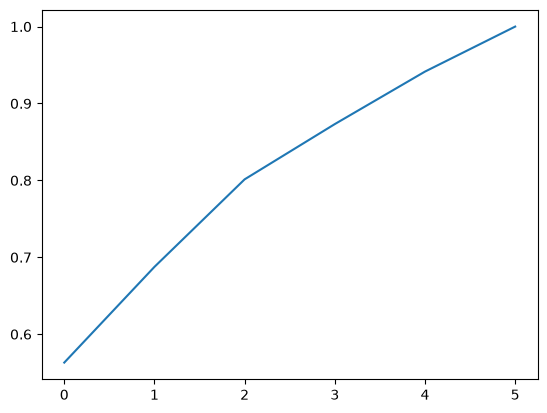

In [60]:
sns.lineplot(cumsum)

In [61]:
#see elbowing at n_comp=2, but falls below least conservative cut off point of 70%

In [62]:
pca_3 = PCA(n_components=3)
X_pca = pca_3.fit_transform(pca_data_scaled)

df_pca = pd.DataFrame(X_pca, columns=['Spend_PC1', 'Spend_PC2', 'Spend_PC3'])

X_cluster = pd.concat([
    df_pca, 
    data[['income', 'has_child', 'web', 'catalogue', 'store']].reset_index(drop=True)
], axis=1)

In [63]:
X_cluster_scaled = scaler.fit_transform(X_cluster)

k=2: silhouette=0.3848 inertia=11231.3076
k=3: silhouette=0.3635 inertia=9197.5660
k=4: silhouette=0.3575 inertia=8219.8209
k=5: silhouette=0.3488 inertia=7484.3578
k=6: silhouette=0.3505 inertia=7095.5600
k=7: silhouette=0.3407 inertia=6518.5616
k=8: silhouette=0.3111 inertia=6079.0340
k=9: silhouette=0.2961 inertia=5891.9936
k=10: silhouette=0.3042 inertia=5519.0662


C:\Users\clair\AppData\Local\Temp\ipykernel_3576\3688033696.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


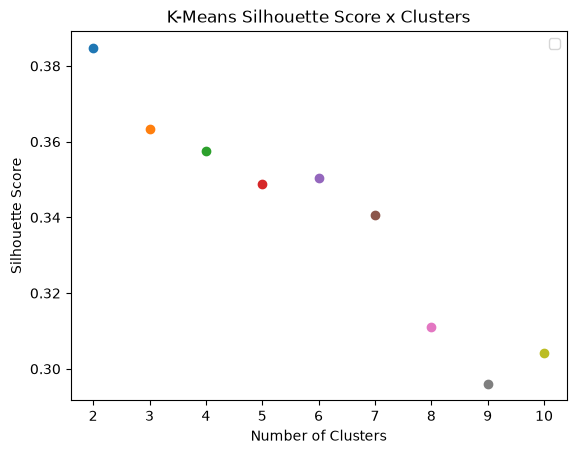

In [64]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=0)
    labels = km.fit_predict(X_cluster_scaled)
    score = silhouette_score(X_cluster_scaled, labels)
    print(f"k={k}: silhouette={score:.4f} inertia={km.inertia_:.4f}")
    plt.scatter(k,score)
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("K-Means Silhouette Score x Clusters")
plt.legend()
plt.show()

In [65]:
#highest silhouette is for 2,3. Large drop in inertia moving from 2-3, as 3 clusters provides greater marketing specificity it is advantageous.

In [66]:
final_kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
data['Cluster'] = final_kmeans.fit_predict(X_cluster_scaled)
print(data['Cluster'].value_counts())

# Profile each cluster
profile_cols = ['income', 'age', 'has_child', 'wines', 'meat', 'webvisits', 'total_spend','num_children']
print(data.groupby('Cluster')[profile_cols].mean())

Cluster
1    1059
2     643
0     510
Name: count, dtype: int64
               income        age  has_child       wines        meat  \
Cluster                                                               
0        76437.270588  45.764706   0.066667  604.380392  473.827451   
1        34698.657224  42.973560   0.878187   45.217186   24.326723   
2        60970.455677  48.027994   0.958009  496.387247  158.718507   

         webvisits  total_spend  num_children  
Cluster                                        
0         2.670588  1382.535294      0.072549  
1         6.459868   103.649669      1.241737  
2         5.548989   821.802488      1.157076  


In [130]:
data.to_csv("../data/clean/data_w_cluster.csv", index=False, encoding= "utf-8", sep = ";")

In [131]:
data.shape

(2212, 25)

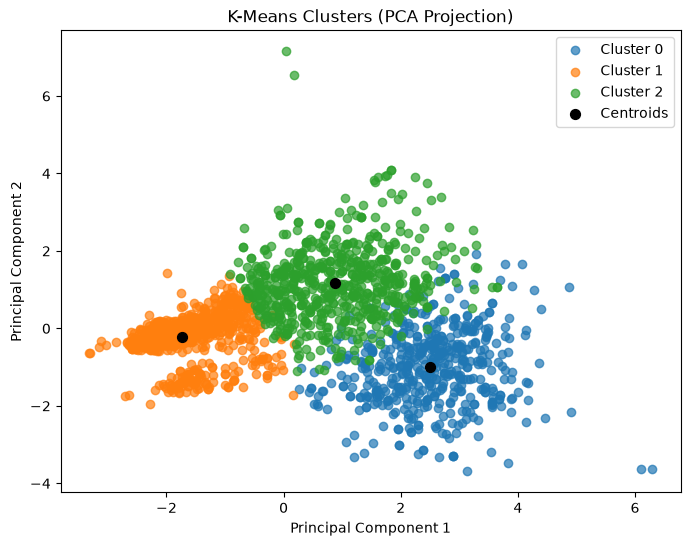

In [67]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster_scaled)
centroids_pca = pca.transform(final_kmeans.cluster_centers_)

plt.figure(figsize=(8, 6))

for i in range(3):
    mask = data['Cluster'] == i
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=f'Cluster {i}',
        alpha=0.7
    )

plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    c='black',
    s=50,
   # marker='X',
    label='Centroids'
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters (PCA Projection)")
plt.legend()
plt.show()

In [119]:
pca = PCA()
pca.fit(X_cluster_scaled)
cumsum = np.cumsum(pca.explained_variance_ratio_)
d = np.argmax(cumsum >=0.75) +1
d,cumsum

(np.int64(4),
 array([0.45944757, 0.61669607, 0.74335343, 0.83475515, 0.89345445,
        0.94753473, 0.98159434, 1.        ]))

In [68]:
feature_cols= ['recency', 'num_camp_success', 'deals', 'webvisits','total_spend', 'income', 'customer_tenure_in_days', 'age', 'education', 
               'num_children','marital_status','Cluster'] 
features = data[feature_cols]
target= data.response

In [69]:
mapping = {
    'Undergraduate': 0,
    'Postgraduate': 1,
    'PhD': 2
}

features['education'] = features['education'].map(mapping)

In [70]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size = 0.20, random_state=0)

In [71]:
X_train

,recency,num_camp_success,deals,webvisits,total_spend,income,customer_tenure_in_days,age,education,num_children,marital_status,Cluster
286,34,1,5,5,916,57912.0,106,49,2,1,Separated,2
933,31,0,2,8,995,67893.0,638,39,0,1,Separated,2
813,23,0,1,6,22,16529.0,122,30,1,1,Partnered,1
575,25,2,0,2,2086,92163.0,566,39,1,0,Partnered,0
117,37,0,1,1,1923,79607.0,436,30,1,0,Single,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1033,98,1,6,5,691,44529.0,361,48,1,1,Partnered,2
1731,26,0,5,6,369,44989.0,657,40,1,1,Partnered,2
763,28,0,2,2,1525,72258.0,292,43,1,1,Single,0
835,0,0,3,4,544,65324.0,171,60,2,1,Partnered,2


In [72]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False, drop='first') # To avoid having an sparse_matrix as output

ohe.fit(X_train[['marital_status']]) # The .fit() method determines the unique values of each column
X_train_trans_np = ohe.transform(X_train[['marital_status']])
X_train_trans_np

array([[1., 0.],
       [1., 0.],
       [0., 0.],
       ...,
       [0., 1.],
       [0., 0.],
       [0., 0.]], shape=(1769, 2))

In [73]:
X_train_trans_df = pd.DataFrame(X_train_trans_np, columns=ohe.get_feature_names_out(), index=X_train.index)
X_train_trans_df

,marital_status_Separated,marital_status_Single
286,1.0,0.0
933,1.0,0.0
813,0.0,0.0
575,0.0,0.0
117,0.0,1.0
...,...,...
1033,0.0,0.0
1731,0.0,0.0
763,0.0,1.0
835,0.0,0.0


In [74]:
X_test_trans_np = ohe.transform(X_test[['marital_status']])
X_test_trans_np

array([[0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [1., 0.],
       [0., 0.],
       [1., 0.],
       [0., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [1., 0.],
       [0., 0.],
       [0., 1.],
       [1., 0.],
       [0., 0.],
       [0., 1.],
       [1., 0.],
       [0., 0.],
       [0., 0.],
       [0., 1.],
       [1., 0.],
       [0., 0.],
       [0., 0.],
       [0., 1.],
       [0., 1.],
       [0., 0.],
       [0., 1.],
       [0., 0.],
       [1., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [1., 0.],
       [0., 0.],
       [1., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [1., 0.],
       [0., 0.],
       [0., 1.],
       [0., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.

In [75]:
X_test_trans_df = pd.DataFrame(X_test_trans_np, columns=ohe.get_feature_names_out(), index=X_test.index)
X_test_trans_df

,marital_status_Separated,marital_status_Single
648,0.0,0.0
810,0.0,0.0
1548,0.0,0.0
399,0.0,0.0
1525,0.0,0.0
...,...,...
1,0.0,1.0
1769,0.0,0.0
621,0.0,0.0
1239,0.0,0.0


In [76]:
X_train_full = pd.concat([X_train_trans_df, X_train.drop(columns=['marital_status'])], axis=1)
X_test_full  = pd.concat([X_test_trans_df, X_test.drop(columns=['marital_status'])], axis=1)

std_scaler = StandardScaler()

std_scaler.fit(X_train_full)

X_train_full_np = std_scaler.transform(X_train_full)
X_test_full_np  = std_scaler.transform(X_test_full)

X_train_full_np_df = pd.DataFrame(X_train_full_np, columns=X_train_full.columns, index=X_train_full.index)
X_test_full_np_df  = pd.DataFrame(X_test_full_np, columns=X_test_full.columns, index=X_test_full.index)


In [77]:
X_train_full_np_df, X_test_full_np_df

(      marital_status_Separated  marital_status_Single   recency  \
 286                   2.470712              -0.513392 -0.526307   
 933                   2.470712              -0.513392 -0.629951   
 813                  -0.404742              -0.513392 -0.906336   
 575                  -0.404742              -0.513392 -0.837240   
 117                  -0.404742               1.947829 -0.422663   
 ...                        ...                    ...       ...   
 1033                 -0.404742              -0.513392  1.684773   
 1731                 -0.404742              -0.513392 -0.802692   
 763                  -0.404742               1.947829 -0.733596   
 835                  -0.404742              -0.513392 -1.700943   
 1653                 -0.404742              -0.513392  0.164655   
 
       num_camp_success     deals  webvisits  total_spend    income  \
 286           1.031205  1.351093  -0.120957     0.499564  0.271996   
 933          -0.445881 -0.170284   1.12

In [78]:
from sklearn.ensemble import RandomForestClassifier
forest = RandomForestClassifier(n_estimators=100,
                             max_depth=20,class_weight="balanced")

In [79]:
forest.fit(X_train_full_np, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fash

In [80]:
y_pred_test_rf = forest.predict(X_test_full_np_df)
print(f"Accuracy score, {forest.score(X_test_full_np_df, y_test): .2f}")

Accuracy score,  0.86


C:\Users\clair\documents\ironhack\final_project\Final-Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\clair\documents\ironhack\final_project\Final-Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [81]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_test_rf))

              precision    recall  f1-score   support

           0       0.93      0.91      0.92       378
           1       0.53      0.58      0.55        65

    accuracy                           0.86       443
   macro avg       0.73      0.75      0.74       443
weighted avg       0.87      0.86      0.87       443



In [82]:
pd.Series(
    forest.feature_importances_,
    index=X_train_full_np_df.columns
).sort_values(ascending=False)

recency                     0.159258
total_spend                 0.142139
customer_tenure_in_days     0.139089
num_camp_success            0.137696
income                      0.105215
age                         0.079161
webvisits                   0.071480
deals                       0.042384
Cluster                     0.033715
num_children                0.026212
education                   0.024885
marital_status_Single       0.021620
marital_status_Separated    0.017146
dtype: float64

In [83]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report


demo_cols = ['age', 'income', 'education','num_children', 'marital_status_Single', 'marital_status_Separated']
digital_cols = ['webvisits', 'deals', 'recency']
hybrid_cols = ['customer_tenure_in_days', 'num_camp_success', 'Cluster', 'total_spend']
global_cols = list(X_train_full_np_df.columns)  # Uses all columns

feature_sets = {
    "Model A (Demographics)": demo_cols,
    "Model B (Digital)": digital_cols,
    "Model C (Relationship/Hybrid)": hybrid_cols,
    "Global Model (All Data)": global_cols
}

# 2. Run the loop across your existing Train/Test split
for model_name, cols in feature_sets.items():
    # Initialize baseline model
    rf = RandomForestClassifier(random_state=42)
    
    # Train only on the specific column subset
    rf.fit(X_train_full_np_df[cols], y_train)
    
    # Predict probabilities for ROC-AUC
    probs = rf.predict_proba(X_test_full_np_df[cols])[:, 1]
    y_pred = rf.predict(X_test_full_np_df[cols])
    auc_score = roc_auc_score(y_test, probs)
    
    print(f"=== {model_name} ===")
    print(f"ROC-AUC Score: {auc_score:.4f}")
    print("-" * 40)
    print(classification_report(y_test, y_pred))

=== Model A (Demographics) ===
ROC-AUC Score: 0.7018
----------------------------------------
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       378
           1       0.51      0.28      0.36        65

    accuracy                           0.86       443
   macro avg       0.70      0.62      0.64       443
weighted avg       0.83      0.86      0.84       443

=== Model B (Digital) ===
ROC-AUC Score: 0.6773
----------------------------------------
              precision    recall  f1-score   support

           0       0.87      0.92      0.89       378
           1       0.32      0.23      0.27        65

    accuracy                           0.81       443
   macro avg       0.60      0.57      0.58       443
weighted avg       0.79      0.81      0.80       443

=== Model C (Relationship/Hybrid) ===
ROC-AUC Score: 0.7573
----------------------------------------
              precision    recall  f1-score   support

       

In [84]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define hyperparameters that constrain complexity and handle imbalance
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 8, 12],
    'min_samples_leaf': [2, 4, 6],
    'class_weight': ['balanced', 'balanced_subsample']  
}

# Target Model C columns
hybrid_cols = ['customer_tenure_in_days', 'num_camp_success', 'Cluster', 'total_spend']

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search.fit(X_train_full_np_df[hybrid_cols], y_train)

print(f"Optimized Model C Best CV ROC-AUC: {grid_search.best_score_:.4f}")
print(f"Best Parameters: {grid_search.best_params_}")

Optimized Model C Best CV ROC-AUC: 0.8119
Best Parameters: {'class_weight': 'balanced_subsample', 'max_depth': 5, 'min_samples_leaf': 6, 'n_estimators': 100}


In [85]:
best_model_c = grid_search.best_estimator_

probs_tuned = best_model_c.predict_proba(X_test_full_np_df[hybrid_cols])[:, 1]
preds_tuned = best_model_c.predict(X_test_full_np_df[hybrid_cols])

print(f"Tuned Model C Test ROC-AUC: {roc_auc_score(y_test, probs_tuned):.4f}")
print(classification_report(y_test, preds_tuned))

Tuned Model C Test ROC-AUC: 0.8086
              precision    recall  f1-score   support

           0       0.92      0.81      0.86       378
           1       0.34      0.57      0.43        65

    accuracy                           0.77       443
   macro avg       0.63      0.69      0.64       443
weighted avg       0.83      0.77      0.80       443



In [86]:
for model_name, cols in feature_sets.items():
    rf = RandomForestClassifier(**grid_search.best_params_, random_state=42)
    rf.fit(X_train_full_np_df[cols], y_train)
    probs = rf.predict_proba(X_test_full_np_df[cols])[:, 1]
    print(f"{model_name}: {roc_auc_score(y_test, probs):.4f}")

Model A (Demographics): 0.7120
Model B (Digital): 0.7054
Model C (Relationship/Hybrid): 0.8086
Global Model (All Data): 0.8729


In [87]:
pd.Series(
    forest.feature_importances_,
    index=X_train_full_np_df.columns
).sort_values(ascending=False)

recency                     0.159258
total_spend                 0.142139
customer_tenure_in_days     0.139089
num_camp_success            0.137696
income                      0.105215
age                         0.079161
webvisits                   0.071480
deals                       0.042384
Cluster                     0.033715
num_children                0.026212
education                   0.024885
marital_status_Single       0.021620
marital_status_Separated    0.017146
dtype: float64

In [88]:
from sklearn.metrics import classification_report, confusion_matrix

# Initialize the model with your verified best parameters
final_rf = RandomForestClassifier(
    class_weight='balanced_subsample',
    max_depth=5,
    min_samples_leaf=6,
    n_estimators=200,
    random_state=42
)

# Fit on the full Global training data
global_cols = list(X_train_full_np_df.columns)
final_rf.fit(X_train_full_np_df[global_cols], y_train)
probs_rf = rf.predict_proba(X_test_full_np_df[cols])[:, 1]

# Predict on the test set
y_pred = final_rf.predict(X_test_full_np_df[global_cols])

print("=== Final Optimized Global Model Metrics ===")
print(classification_report(y_test, y_pred))

=== Final Optimized Global Model Metrics ===
              precision    recall  f1-score   support

           0       0.94      0.86      0.90       378
           1       0.45      0.69      0.55        65

    accuracy                           0.83       443
   macro avg       0.70      0.77      0.72       443
weighted avg       0.87      0.83      0.85       443



In [89]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define hyperparameters that constrain complexity and handle imbalance
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 8, 12],
    'min_samples_leaf': [2, 4, 6],
    'class_weight': ['balanced', 'balanced_subsample']  
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search.fit(X_train_full_np_df[global_cols], y_train)

print(f"Optimized Global Model ROC-AUC: {grid_search.best_score_:.4f}")
print(f"Best Parameters: {grid_search.best_params_}")

Optimized Global Model ROC-AUC: 0.8851
Best Parameters: {'class_weight': 'balanced', 'max_depth': 8, 'min_samples_leaf': 4, 'n_estimators': 200}


In [114]:
from sklearn.metrics import classification_report, confusion_matrix

# Initialize the model with your verified best parameters
final_rf = RandomForestClassifier(
    class_weight='balanced',
    max_depth=8,
    min_samples_leaf=4,
    n_estimators=200,
    random_state=42
)

# Fit on the full Global training data
global_cols = list(X_train_full_np_df.columns)
final_rf.fit(X_train_full_np_df[global_cols], y_train)

probs_rf = final_rf.predict_proba(X_test_full_np_df)[:, 1]

# Predict on the test set
y_pred_rf = final_rf.predict(X_test_full_np_df[global_cols])

print("=== Final Optimized Global Model Metrics ===")
print(classification_report(y_test, y_pred))

=== Final Optimized Global Model Metrics ===
              precision    recall  f1-score   support

           0       0.91      0.97      0.94       378
           1       0.74      0.45      0.56        65

    accuracy                           0.90       443
   macro avg       0.83      0.71      0.75       443
weighted avg       0.89      0.90      0.88       443



In [91]:
data.groupby('Cluster')['response'].mean()

Cluster
0    0.301961
1    0.094429
2    0.122862
Name: response, dtype: float64

In [92]:
from scipy.stats import ttest_ind
conv_success = data[data['response'] == 1].Cluster
conv_failure = data[data['response'] == 0].Cluster
t_stat, p_value = ttest_ind(conv_success, conv_failure, equal_var=False, alternative="two-sided") 
print(p_value)

3.908149176302273e-12


In [93]:
# while clusters didn't rate highly with the random forest model, this is likely because decision trees themselves are capable of
#discovering clusters through nodes. However, as there is a correlation between clusters and success, a model such as logistic 
#regression may be improved with them.

In [94]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()
log_reg.fit(X_train_full_np_df, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [95]:
y_pred = log_reg.predict(X_test_full_np_df)

In [96]:
print(f"Accuracy score, {log_reg.score(X_test_full_np_df, y_test): .2f}")
probs = log_reg.predict_proba(X_test_full_np_df)[:, 1]
print(f"ROC_AUC, {roc_auc_score(y_test, probs):.4f}")
print(classification_report(y_test, y_pred))

Accuracy score,  0.90
ROC_AUC, 0.8616
              precision    recall  f1-score   support

           0       0.91      0.98      0.94       378
           1       0.76      0.45      0.56        65

    accuracy                           0.90       443
   macro avg       0.84      0.71      0.75       443
weighted avg       0.89      0.90      0.89       443



In [97]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Define the parameter values to be searched
# param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}

param_grid = {
    'penalty': ['l1', 'l2', 'elasticnet'],
    'C': np.logspace(-3, 3, 10),
    'solver': ['saga'],
    'l1_ratio': [0, 0.5, 1],  # only used for elasticnet
    'max_iter': [1000]
}

# Instantiate the grid
grid_search = GridSearchCV(LogisticRegression(max_iter=10000), param_grid, cv=5)

# Fit the grid with data
grid_search.fit(X_train_full_np_df, y_train)

C:\Users\clair\documents\ironhack\final_project\Final-Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\clair\documents\ironhack\final_project\Final-Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\Users\clair\documents\ironhack\final_project\Final-Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, 

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ax_iter=10000)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': array([1.0000...00000000e+03]), 'l1_ratio': [0, 0.5, ...], 'max_iter': [1000], 'penalty': ['l1', 'l2', ...], ...}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose 

In [98]:
# Printing the best parameters
print("Best parameters:", grid_search.best_params_)

Best parameters: {'C': np.float64(0.1), 'l1_ratio': 0.5, 'max_iter': 1000, 'penalty': 'elasticnet', 'solver': 'saga'}


In [99]:
log_reg = LogisticRegression(random_state=42,C=0.1,max_iter=100,penalty='l2',solver='lbfgs')
log_reg.fit(X_train_full_np_df, y_train)

C:\Users\clair\documents\ironhack\final_project\Final-Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver becaus

In [100]:
y_pred = log_reg.predict(X_test_full_np_df)

In [101]:
print(f"Accuracy score, {log_reg.score(X_test_full_np_df, y_test): .2f}")
probs_lr = log_reg.predict_proba(X_test_full_np_df)[:, 1]
print(f"ROC_AUC, {roc_auc_score(y_test, probs):.4f}")
print(classification_report(y_test, y_pred))

Accuracy score,  0.89
ROC_AUC, 0.8616
              precision    recall  f1-score   support

           0       0.91      0.98      0.94       378
           1       0.75      0.42      0.53        65

    accuracy                           0.89       443
   macro avg       0.83      0.70      0.74       443
weighted avg       0.88      0.89      0.88       443



In [102]:
log_reg.fit(X_train_full_np_df.drop(columns=['Cluster']), y_train)
y_pred = log_reg.predict(X_test_full_np_df.drop(columns=['Cluster']))
print(f"Accuracy score, {log_reg.score(X_test_full_np_df.drop(columns=['Cluster']), y_test): .2f}")
probs = log_reg.predict_proba(X_test_full_np_df.drop(columns=['Cluster']))[:, 1]
print(f"ROC_AUC, {roc_auc_score(y_test, probs):.4f}")
print(classification_report(y_test, y_pred))

C:\Users\clair\documents\ironhack\final_project\Final-Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Accuracy score,  0.90
ROC_AUC, 0.8562
              precision    recall  f1-score   support

           0       0.91      0.98      0.94       378
           1       0.77      0.42      0.54        65

    accuracy                           0.90       443
   macro avg       0.84      0.70      0.74       443
weighted avg       0.89      0.90      0.88       443



In [103]:
from MLstatkit.stats import Delong_test

In [116]:
# z_score, p_value = Delong_test(y_test,  y_pred_rf, probs_lr)
# print(f"Z-Score: {z_score}, P-Value: {p_value}")

z, p, ci_A, ci_B, auc_A, auc_B, info = Delong_test(
    y_test,  probs_rf, probs_lr,
    alpha=0.95, return_ci=True, return_auc=True, verbose=1
)

print(f"Method   : {info['method']}")
print(f"AUC_A    : {auc_A:.4f}, CI_A = {ci_A}")
print(f"AUC_B    : {auc_B:.4f}, CI_B = {ci_B}")
print(f"z-score  : {z:.4f}, p-value = {p:.3e}")

=== DeLong Test ===
Samples: total=443, pos=65, neg=378
Tie rate: A=0.036, B=0.036
Step 1) Attempt standard DeLong.
[delong] z = -1.337495, p = 1.811e-01
Method   : delong
AUC_A    : 0.8850, CI_A = (0.8454433412206533, 0.9246014288241166)
AUC_B    : 0.8630, CI_B = (0.8135914428494079, 0.912334483076518)
z-score  : -1.3375, p-value = 1.811e-01


In [106]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor( random_state=42)

xgb_model.fit(X_train_full_np_df, y_train)

y_pred_xgb = xgb_model.predict(X_test_full_np_df)

xgb_roc=roc_auc_score(y_test, y_pred_xgb)
print(f"ROC_AUC, {roc_auc_score(y_test, y_pred_xgb):.4f}")

ROC_AUC, 0.8022


In [107]:
from xgboost import XGBClassifier

param_grid = {
    'max_depth': [3, 5, 7],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'learning_rate': [0.01, 0.1, 0.3]
}
xgb = XGBClassifier(n_estimators=100, objective='binary:logistic', random_state=42)

grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)


grid_search.fit(X_train_full_np_df, y_train)

print("Best parameters:", grid_search.best_params_)
print(f"Best score: {grid_search.best_score_}")

Fitting 3 folds for each of 243 candidates, totalling 729 fits
Best parameters: {'colsample_bytree': 0.6, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 3, 'subsample': 0.8}


In [110]:
xgb_clf = XGBClassifier(colsample_bytree= 0.6, learning_rate= 0.1, max_depth= 3, min_child_weight= 3, subsample= 0.8, random_state=42)
xgb_clf.fit(X_train_full_np_df, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.6
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [112]:
y_pred = xgb_clf.predict(X_test_full_np_df)
print(f"Accuracy score, {xgb_clf.score(X_test_full_np_df, y_test): .2f}")
probs_xgb = xgb_clf.predict_proba(X_test_full_np_df)[:, 1]
print(f"ROC_AUC, {roc_auc_score(y_test, probs_xgb):.4f}")
print(classification_report(y_test, y_pred))

Accuracy score,  0.90
ROC_AUC, 0.9015
              precision    recall  f1-score   support

           0       0.91      0.97      0.94       378
           1       0.74      0.45      0.56        65

    accuracy                           0.90       443
   macro avg       0.83      0.71      0.75       443
weighted avg       0.89      0.90      0.88       443



In [132]:
pd.Series(
    xgb_clf.feature_importances_,
    index=X_train_full_np_df.columns
).sort_values(ascending=False)

num_camp_success            0.214292
recency                     0.102865
marital_status_Single       0.090950
Cluster                     0.076642
total_spend                 0.075456
customer_tenure_in_days     0.075374
marital_status_Separated    0.073372
webvisits                   0.061249
income                      0.056697
education                   0.050698
num_children                0.047033
deals                       0.041535
age                         0.033836
dtype: float32

In [117]:
z, p, ci_A, ci_B, auc_A, auc_B, info = Delong_test(
    y_test,  probs_rf, probs_xgb,
    alpha=0.95, return_ci=True, return_auc=True, verbose=1
)

print(f"Method   : {info['method']}")
print(f"AUC_A    : {auc_A:.4f}, CI_A = {ci_A}")
print(f"AUC_B    : {auc_B:.4f}, CI_B = {ci_B}")
print(f"z-score  : {z:.4f}, p-value = {p:.3e}")

=== DeLong Test ===
Samples: total=443, pos=65, neg=378
Tie rate: A=0.036, B=0.036
Step 1) Attempt standard DeLong.
[delong] z = 2.158334, p = 3.090e-02
Method   : delong
AUC_A    : 0.8850, CI_A = (0.8454433412206533, 0.9246014288241166)
AUC_B    : 0.9015, CI_B = (0.8636963921709835, 0.9393968109222195)
z-score  : 2.1583, p-value = 3.090e-02


In [118]:
z, p, ci_A, ci_B, auc_A, auc_B, info = Delong_test(
    y_test,  probs_lr, probs_xgb,
    alpha=0.95, return_ci=True, return_auc=True, verbose=1
)

print(f"Method   : {info['method']}")
print(f"AUC_A    : {auc_A:.4f}, CI_A = {ci_A}")
print(f"AUC_B    : {auc_B:.4f}, CI_B = {ci_B}")
print(f"z-score  : {z:.4f}, p-value = {p:.3e}")

=== DeLong Test ===
Samples: total=443, pos=65, neg=378
Tie rate: A=0.036, B=0.036
Step 1) Attempt standard DeLong.
[delong] z = 2.977276, p = 2.908e-03
Method   : delong
AUC_A    : 0.8630, CI_A = (0.8135914428494079, 0.912334483076518)
AUC_B    : 0.9015, CI_B = (0.8636963921709835, 0.9393968109222195)
z-score  : 2.9773, p-value = 2.908e-03


In [ ]:
# from imblearn.over_sampling import RandomOverSampler

# over = RandomOverSampler(random_state=42)
# X_train_over, y_train_over = over.fit_resample(X_train_full_np, y_train)

In [ ]:
# forest.fit(X_train_over, y_train_over)

In [ ]:
# y_pred_test_rf = forest.predict(X_test_full_np_df)

# print(f"Accuracy score, {forest.score(X_test_full_np_df, y_test): .2f}")

In [ ]:
# from sklearn.metrics import classification_report
# print(classification_report(y_test, y_pred_test_rf))

In [ ]:
# pd.Series(
#     forest.feature_importances_,
#     index=X_train_full_np_df.columns
# ).sort_values(ascending=False)